Install required libraries

In [2]:
!pip install pandas numpy matplotlib plotly streamlit openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 122.2 MB/s eta 0:00:00


Install required libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import streamlit as st

%matplotlib inline

Upload Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel("/content/drive/MyDrive/HHS_Unaccompanied_Alien_Children_Program.xlsx")

Mounted at /content/drive


Read the dataset

In [5]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6,18,11,2484,14
1,2025-12-18,11,50,6,2472,16
2,2025-12-17,7,31,11,2481,10
3,2025-12-16,8,54,15,2468,9
4,2025-12-15,11,42,9,2470,7


Check dataset information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    int64         
 2   Children in CBP custody                          720 non-null    int64         
 3   Children transferred out of CBP custody          720 non-null    int64         
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 33.9 KB


Check missing values

In [7]:
df.isnull().sum()

,0
Date,0
Children apprehended and placed in CBP custody*,0
Children in CBP custody,0
Children transferred out of CBP custody,0
Children in HHS Care,0
Children discharged from HHS Care,0


Check duplicate rows

In [8]:
df.duplicated().sum()

np.int64(0)

Convert the Date column

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

Sort by date

In [10]:
df = df.sort_values("Date")
df.reset_index(drop=True, inplace=True)


Check the data types

In [11]:
df.dtypes

,0
Date,datetime64[ns]
Children apprehended and placed in CBP custody*,int64
Children in CBP custody,int64
Children transferred out of CBP custody,int64
Children in HHS Care,int64
Children discharged from HHS Care,int64


Save the cleaned dataset

In [12]:
df.to_excel("cleaned_uac_data.xlsx", index=False)

**Exploratory Data Analysis (EDA)**

In [13]:
df.describe()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841


Shape of the Dataset

In [14]:
print("Rows and Columns:", df.shape)

Rows and Columns: (720, 6)


Column Names

In [15]:
print(df.columns)

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


In [16]:
import matplotlib.pyplot as plt

%matplotlib inline

Graph 1 - Daily Children Apprehended

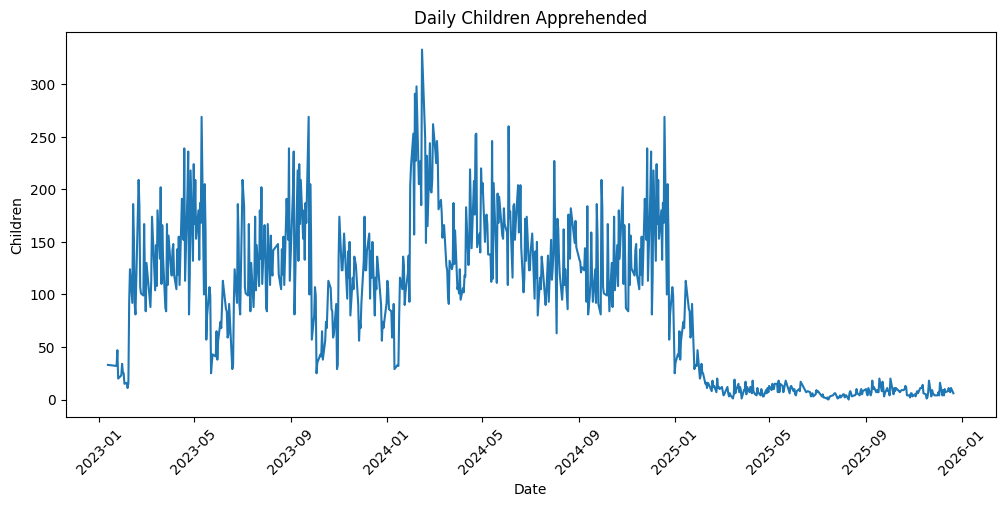

In [19]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Children apprehended and placed in CBP custody*"])

plt.title("Daily Children Apprehended")
plt.xlabel("Date")
plt.ylabel("Children")

plt.xticks(rotation=45)

plt.show()

Graph 2 - Children in CBP Custody

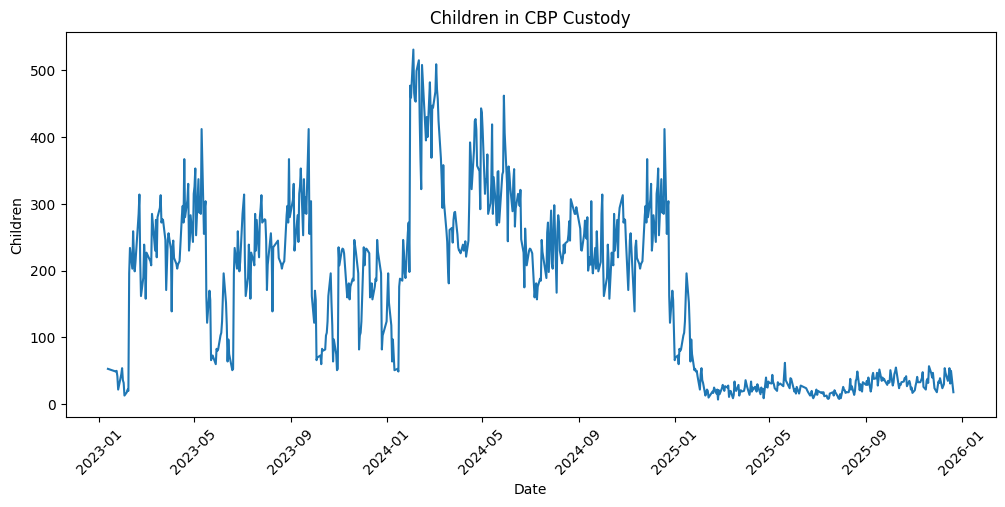

In [20]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Children in CBP custody"])

plt.title("Children in CBP Custody")
plt.xlabel("Date")
plt.ylabel("Children")

plt.xticks(rotation=45)

plt.show()

Graph 3 - Children Transferred to HHS

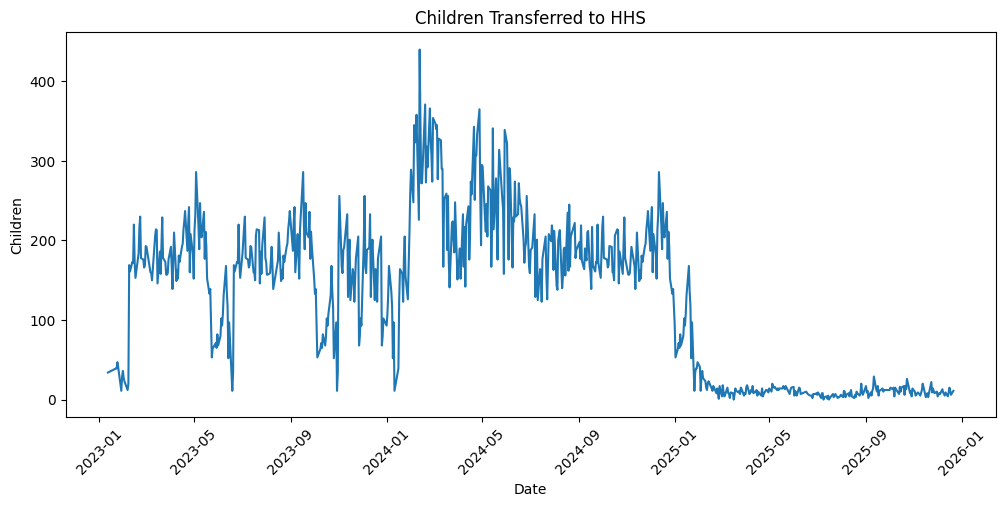

In [21]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Children transferred out of CBP custody"])

plt.title("Children Transferred to HHS")
plt.xlabel("Date")
plt.ylabel("Children")

plt.xticks(rotation=45)

plt.show()

Graph 4 - Children in HHS Care

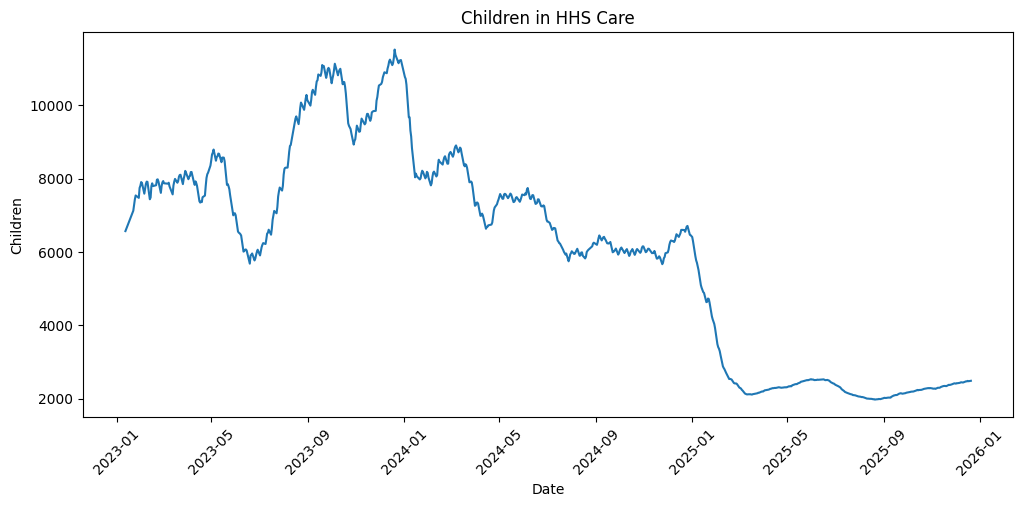

In [22]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Children in HHS Care"])

plt.title("Children in HHS Care")
plt.xlabel("Date")
plt.ylabel("Children")

plt.xticks(rotation=45)

plt.show()

Graph 5 - Children Discharged

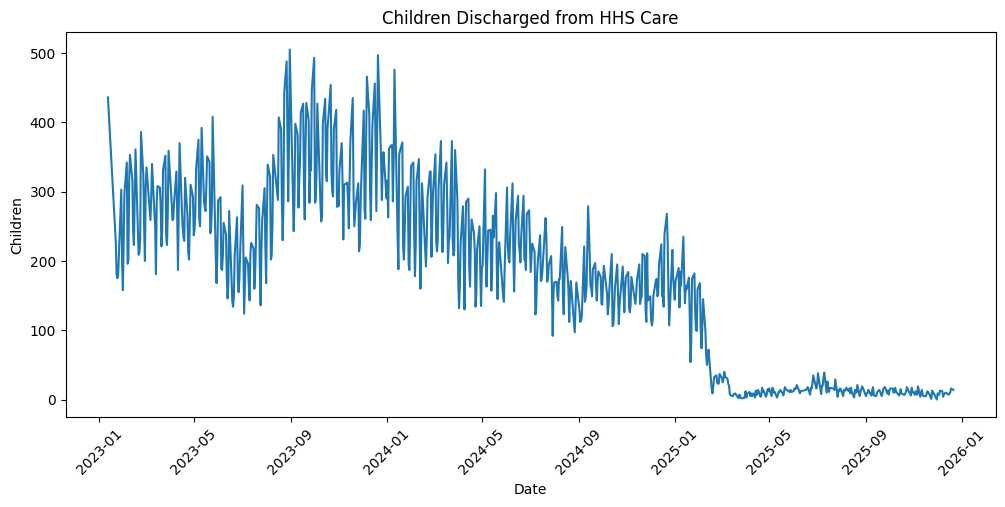

In [23]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Children discharged from HHS Care"])

plt.title("Children Discharged from HHS Care")
plt.xlabel("Date")
plt.ylabel("Children")

plt.xticks(rotation=45)

plt.show()

Correlation Matrix

In [24]:
df.corr(numeric_only=True)

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Children apprehended and placed in CBP custody*,1.000000,0.950604,0.887896,0.691312,0.627755
Children in CBP custody,0.950604,1.000000,0.925039,0.663662,0.602144
Children transferred out of CBP custody,0.887896,0.925039,1.000000,0.713899,0.657322
Children in HHS Care,0.691312,0.663662,0.713899,1.000000,0.920881
Children discharged from HHS Care,0.627755,0.602144,0.657322,0.920881,1.000000


Histogram

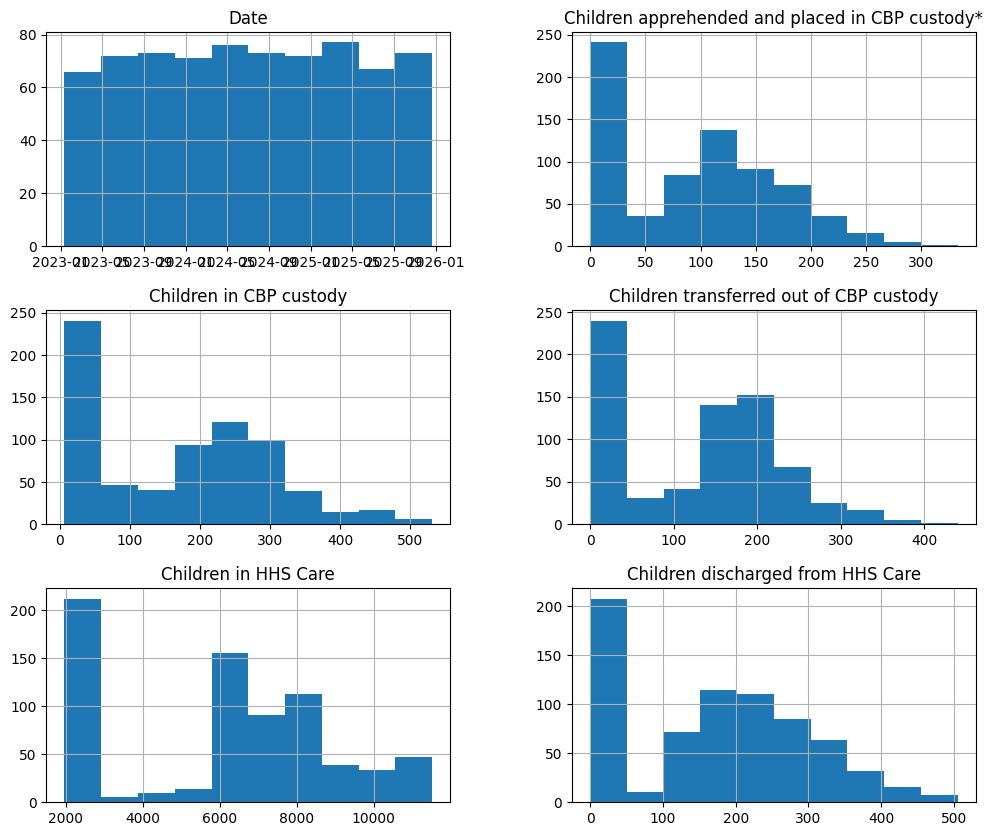

In [25]:
df.hist(figsize=(12,10))

plt.show()

Box Plot

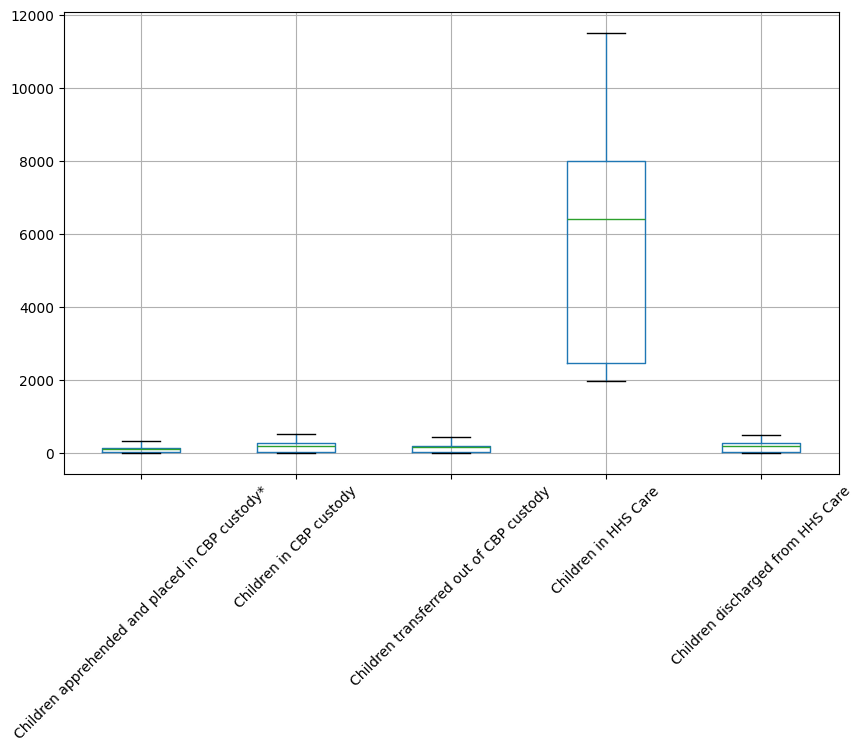

In [26]:
plt.figure(figsize=(10,6))

df.boxplot()

plt.xticks(rotation=45)

plt.show()

**Feature Engineering**

Total System Load

In [ ]:
### Children in CBP Custody + Children in HHS Care

In [27]:
df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

In [31]:
df[["Date", "Total System Load"]].head(10)

,Date,Total System Load
0,2023-01-12,6619
1,2023-01-22,7171
2,2023-01-23,7330
3,2023-01-24,7475
4,2023-01-25,7560
5,2023-01-29,7517
6,2023-01-30,7797
7,2023-01-31,7839
8,2023-02-01,7935
9,2023-02-02,7892


Net Intake

In [ ]:
### Children Transferred to HHS − Children Discharged

In [29]:
df["Net Intake"] = (
    df["Children transferred out of CBP custody"] -
    df["Children discharged from HHS Care"]
)

In [30]:
df[["Date", "Net Intake"]].head()

,Date,Net Intake
0,2023-01-12,-402
1,2023-01-22,-188
2,2023-01-23,-142
3,2023-01-24,-128
4,2023-01-25,-139


Care Load Growth Rate

In [32]:
df["Growth Rate (%)"] = (
    df["Total System Load"].pct_change() * 100
)

In [33]:
df[["Date", "Growth Rate (%)"]].head()

,Date,Growth Rate (%)
0,2023-01-12,NaN
1,2023-01-22,8.339628
2,2023-01-23,2.217264
3,2023-01-24,1.978172
4,2023-01-25,1.137124


Backlog

In [34]:
df["Backlog"] = df["Net Intake"].cumsum()

In [35]:
df[["Date", "Backlog"]].head()

,Date,Backlog
0,2023-01-12,-402
1,2023-01-22,-590
2,2023-01-23,-732
3,2023-01-24,-860
4,2023-01-25,-999


In [36]:
df["7-Day Rolling Avg"] = (
    df["Total System Load"]
    .rolling(window=7)
    .mean()
)

7-Day Rolling Average

In [37]:
df[["Date", "7-Day Rolling Avg"]].head(10)

,Date,7-Day Rolling Avg
0,2023-01-12,NaN
1,2023-01-22,NaN
2,2023-01-23,NaN
3,2023-01-24,NaN
4,2023-01-25,NaN
5,2023-01-29,NaN
6,2023-01-30,7352.714286
7,2023-01-31,7527.000000
8,2023-02-01,7636.142857
9,2023-02-02,7716.428571


14-Day Rolling Average

In [38]:
df["14-Day Rolling Avg"] = (
    df["Total System Load"]
    .rolling(window=14)
    .mean()
)

In [39]:
df[["Date", "14-Day Rolling Avg"]].head(15)

,Date,14-Day Rolling Avg
0,2023-01-12,NaN
1,2023-01-22,NaN
2,2023-01-23,NaN
3,2023-01-24,NaN
4,2023-01-25,NaN
5,2023-01-29,NaN
6,2023-01-30,NaN
7,2023-01-31,NaN
8,2023-02-01,NaN
9,2023-02-02,NaN


In [40]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Total System Load,Net Intake,Growth Rate (%),Backlog,7-Day Rolling Avg,14-Day Rolling Avg
0,2023-01-12,33,53,34,6566,436,6619,-402,NaN,-402,NaN,NaN
1,2023-01-22,32,49,39,7122,227,7171,-188,8.339628,-590,NaN,NaN
2,2023-01-23,32,50,39,7280,181,7330,-142,2.217264,-732,NaN,NaN
3,2023-01-24,47,42,47,7433,175,7475,-128,1.978172,-860,NaN,NaN
4,2023-01-25,20,22,41,7538,180,7560,-139,1.137124,-999,NaN,NaN


In [41]:
df.to_excel("UAC_Feature_Engineered_Data.xlsx", index=False)

**KPI (Key Performance Indicator) Calculations.**

Current Total Children Under Care

In [44]:
current_total_load = df["Total System Load"].iloc[-1]

print("Current Total Children Under Care:", current_total_load)

Current Total Children Under Care: 2502


Maximum Total System Load

In [45]:
max_load = df["Total System Load"].max()

print("Maximum Total System Load:", max_load)

Maximum Total System Load: 11762


Average Total System Load

In [46]:
avg_load = df["Total System Load"].mean()

print("Average Total System Load:", round(avg_load,2))

Average Total System Load: 6232.77


Average Net Intake Pressure

In [47]:
avg_net = df["Net Intake"].mean()

print("Average Net Intake:", round(avg_net,2))

Average Net Intake: -44.74


Care Load Volatility Index

In [48]:
volatility = df["Total System Load"].std()

print("Care Load Volatility:", round(volatility,2))

Care Load Volatility: 2918.46


Backlog Accumulation Rate

In [49]:
final_backlog = df["Backlog"].iloc[-1]

print("Final Backlog:", final_backlog)

Final Backlog: -32212


Discharge Offset Ratio

In [50]:
ratio = (
    df["Children discharged from HHS Care"].sum() /
    df["Children transferred out of CBP custody"].sum()
)

print("Discharge Offset Ratio:", round(ratio,2))

Discharge Offset Ratio: 1.35


In [52]:
print("========== KPI SUMMARY ==========")
print("Current Total Load:", current_total_load)
print("Maximum Total Load:", max_load)
print("Average Total Load:", round(avg_load,2))
print("Average Net Intake:", round(avg_net,2))
print("Care Load Volatility:", round(volatility,2))
print("Final Backlog:", final_backlog)
print("Discharge Offset Ratio:", round(ratio,2))

========== KPI SUMMARY ==========
Current Total Load: 2502
Maximum Total Load: 11762
Average Total Load: 6232.77
Average Net Intake: -44.74
Care Load Volatility: 2918.46
Final Backlog: -32212
Discharge Offset Ratio: 1.35


**Create Graphs**

In [53]:
import matplotlib.pyplot as plt

Graph 1: Total System Load Over Time

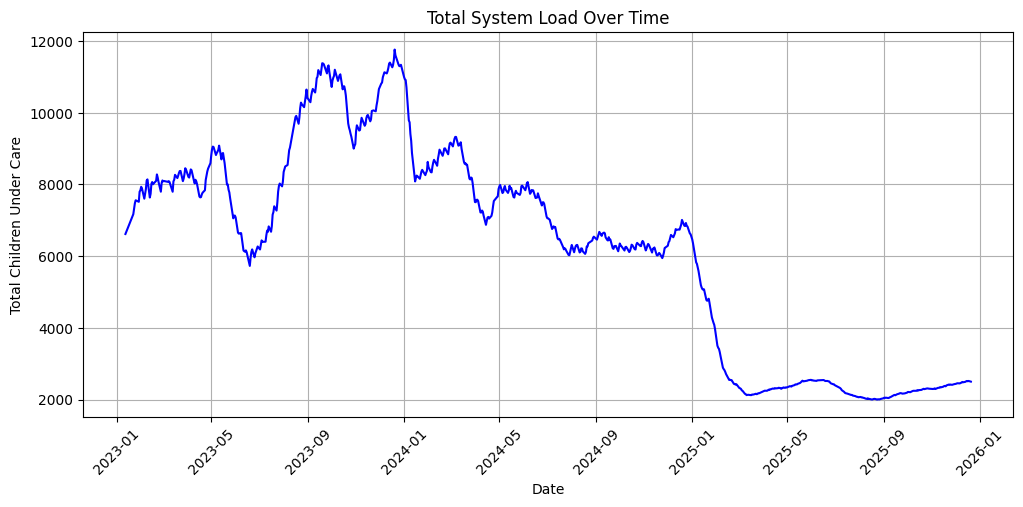

In [54]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Total System Load"], color="blue")

plt.title("Total System Load Over Time")
plt.xlabel("Date")
plt.ylabel("Total Children Under Care")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Graph 2: CBP vs HHS Care

```
# This is formatted as code
```



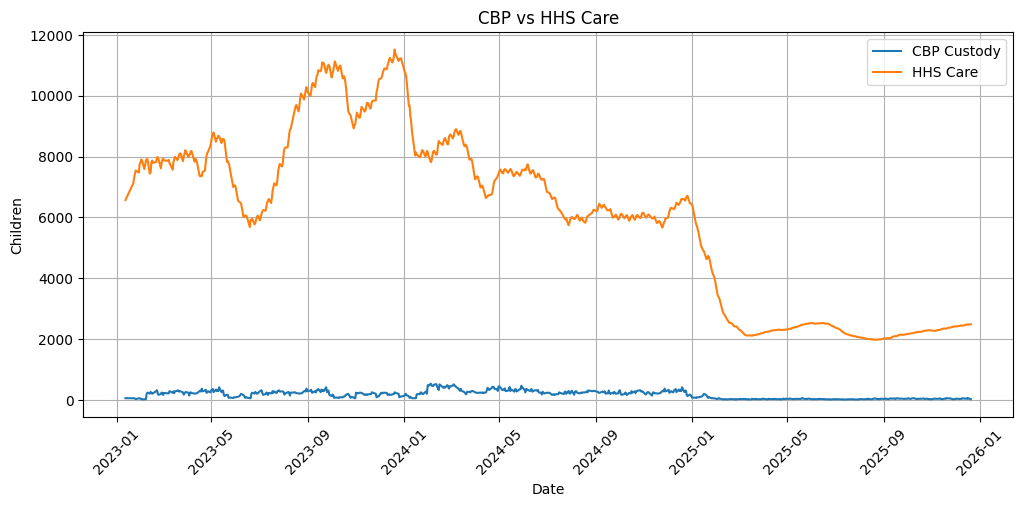

In [55]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Children in CBP custody"], label="CBP Custody")
plt.plot(df["Date"], df["Children in HHS Care"], label="HHS Care")

plt.title("CBP vs HHS Care")
plt.xlabel("Date")
plt.ylabel("Children")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Graph 3: Net Intake Trend

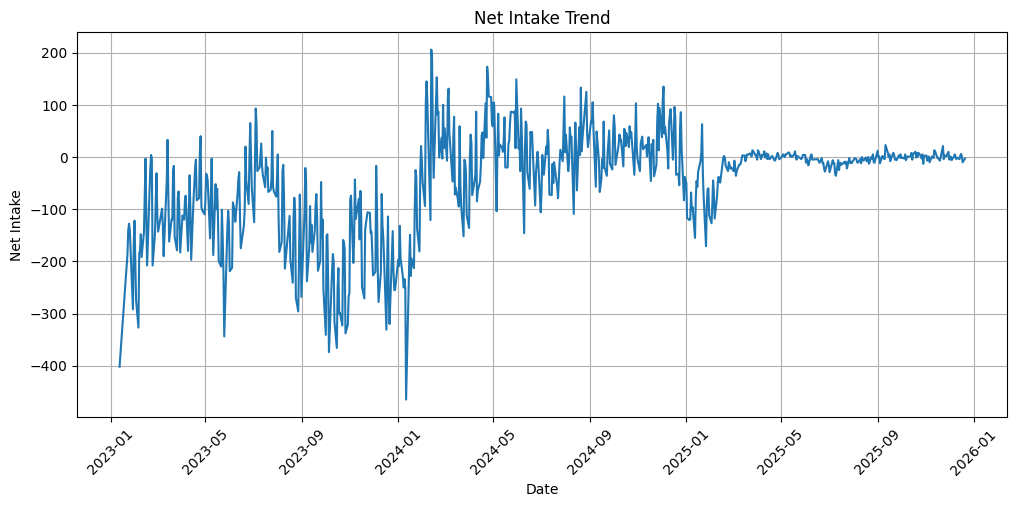

In [56]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Net Intake"])

plt.title("Net Intake Trend")
plt.xlabel("Date")
plt.ylabel("Net Intake")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Graph 4: Backlog Trend

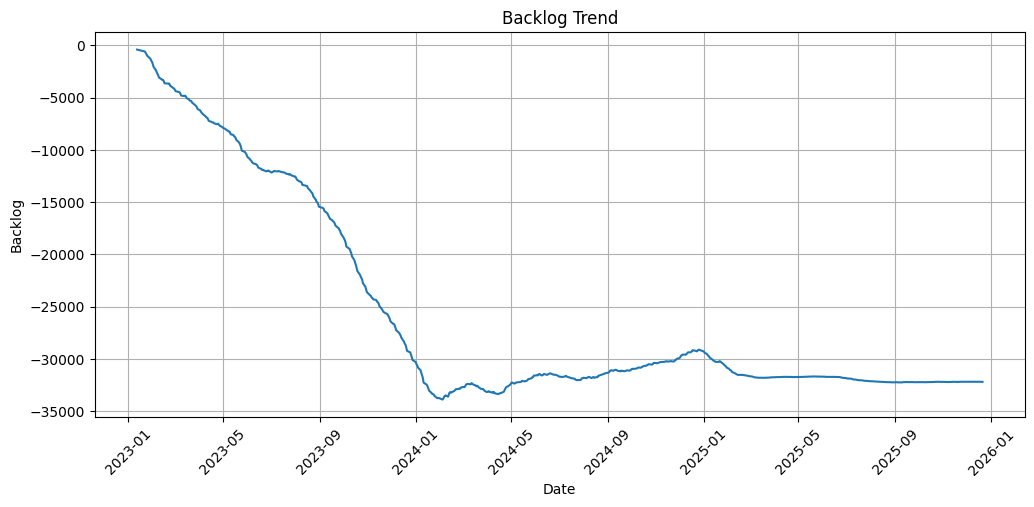

In [57]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Backlog"])

plt.title("Backlog Trend")
plt.xlabel("Date")
plt.ylabel("Backlog")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Graph 5: 7-Day vs 14-Day Rolling Average

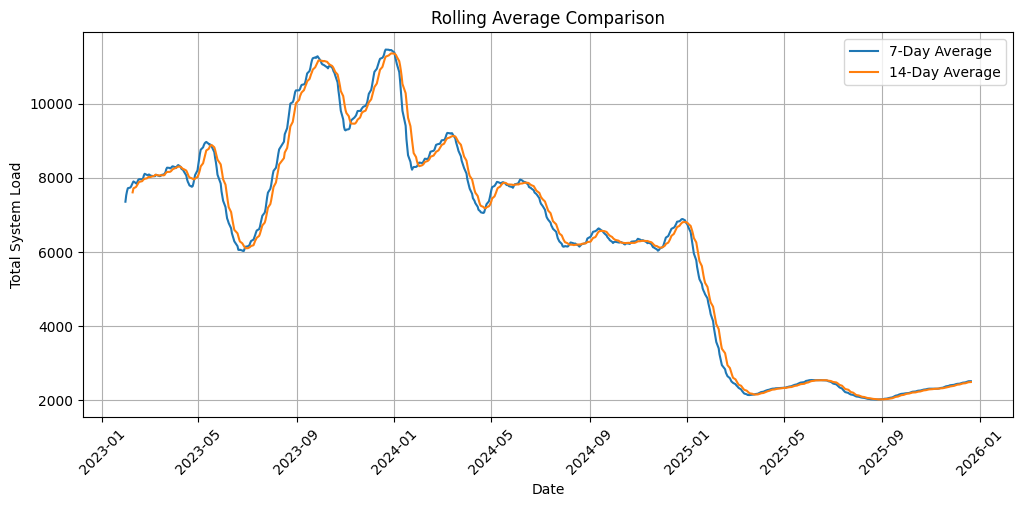

In [58]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["7-Day Rolling Avg"], label="7-Day Average")
plt.plot(df["Date"], df["14-Day Rolling Avg"], label="14-Day Average")

plt.title("Rolling Average Comparison")
plt.xlabel("Date")
plt.ylabel("Total System Load")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Graph 6: Monthly Average Total System Load

In [59]:
df["Month"] = df["Date"].dt.to_period("M")
monthly_avg = df.groupby("Month")["Total System Load"].mean()

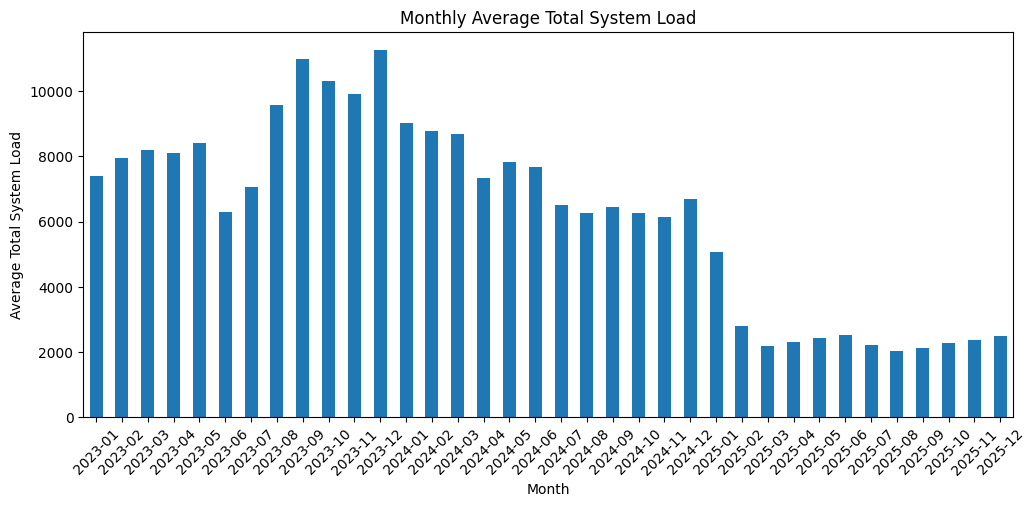

In [60]:
plt.figure(figsize=(12,5))

monthly_avg.plot(kind="bar")

plt.title("Monthly Average Total System Load")
plt.xlabel("Month")
plt.ylabel("Average Total System Load")

plt.xticks(rotation=45)

plt.show()

**Insights**

Highest System Load

In [61]:
max_row = df.loc[df["Total System Load"].idxmax()]

print("Highest System Load:", max_row["Total System Load"])
print("Date:", max_row["Date"])

Highest System Load: 11762
Date: 2023-12-20 00:00:00


Highest Net Intake


In [62]:
net_row = df.loc[df["Net Intake"].idxmax()]

print("Highest Net Intake:", net_row["Net Intake"])
print("Date:", net_row["Date"])

Highest Net Intake: 206
Date: 2024-02-12 00:00:00


Highest Backlog

In [63]:
backlog_row = df.loc[df["Backlog"].idxmax()]

print("Highest Backlog:", backlog_row["Backlog"])
print("Date:", backlog_row["Date"])

Highest Backlog: -402
Date: 2023-01-12 00:00:00


Highest CBP Custody

In [64]:
cbp_row = df.loc[df["Children in CBP custody"].idxmax()]

print(cbp_row["Children in CBP custody"])
print(cbp_row["Date"])

531
2024-02-04 00:00:00


Highest HHS Care

In [65]:
hhs_row = df.loc[df["Children in HHS Care"].idxmax()]

print(hhs_row["Children in HHS Care"])
print(hhs_row["Date"])

11516
2023-12-20 00:00:00


**Building the Streamlit Dashboard**

In [66]:
!pip install streamlit

In [71]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

In [86]:
%%writefile app.py

# -----------------------------
# PAGE SETTINGS
# -----------------------------
st.set_page_config(
    page_title="UAC Healthcare Analytics",
    layout="wide"
)

st.title("📊 System Capacity & Care Load Analytics")
st.write("Healthcare Analytics Dashboard for Unaccompanied Children")

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_excel("UAC_Feature_Engineered_Data.xlsx")

df["Date"] = pd.to_datetime(df["Date"])

# -----------------------------
# SIDEBAR FILTER
# -----------------------------
st.sidebar.header("Filters")

start = st.sidebar.date_input(
    "Start Date",
    df["Date"].min()
)

end = st.sidebar.date_input(
    "End Date",
    df["Date"].max()
)

filtered = df[
    (df["Date"] >= pd.to_datetime(start)) &
    (df["Date"] <= pd.to_datetime(end))
]

# -----------------------------
# KPI CARDS
# -----------------------------
st.subheader("Key Performance Indicators")

col1, col2, col3 = st.columns(3)

col1.metric(
    "Current Load",
    int(filtered["Total System Load"].iloc[-1])
)

col2.metric(
    "Maximum Load",
    int(filtered["Total System Load"].max())
)

col3.metric(
    "Average Load",
    round(filtered["Total System Load"].mean(),2)
)

# -----------------------------
# GRAPH 1
# -----------------------------
st.subheader("Total System Load")

fig = px.line(
    filtered,
    x="Date",
    y="Total System Load"
)

st.plotly_chart(fig, use_container_width=True)

# -----------------------------
# GRAPH 2
# -----------------------------
st.subheader("CBP vs HHS")

fig = px.line(
    filtered,
    x="Date",
    y=[
        "Children in CBP custody",
        "Children in HHS Care"
    ]
)

st.plotly_chart(fig, use_container_width=True)

# -----------------------------
# GRAPH 3
# -----------------------------
st.subheader("Net Intake")

fig = px.line(
    filtered,
    x="Date",
    y="Net Intake"
)

st.plotly_chart(fig, use_container_width=True)

# -----------------------------
# GRAPH 4
# -----------------------------
st.subheader("Backlog")

fig = px.line(
    filtered,
    x="Date",
    y="Backlog"
)

st.plotly_chart(fig, use_container_width=True)

# -----------------------------
# GRAPH 5
# -----------------------------
st.subheader("Rolling Average")

fig = px.line(
    filtered,
    x="Date",
    y=[
        "7-Day Rolling Avg",
        "14-Day Rolling Avg"
    ]
)

st.plotly_chart(fig, use_container_width=True)

# -----------------------------
# INSIGHTS
# -----------------------------
st.subheader("Key Insights")

st.write(
    "Highest System Load:",
    filtered["Total System Load"].max()
)

st.write(
    "Highest Net Intake:",
    filtered["Net Intake"].max()
)

st.write(
    "Highest Backlog:",
    filtered["Backlog"].max()
)

# -----------------------------
# DOWNLOAD
# -----------------------------
st.subheader("Download Data")

csv = filtered.to_csv(index=False)

st.download_button(
    label="Download CSV",
    data=csv,
    file_name="Filtered_Data.csv",
    mime="text/csv"
)

Writing app.py


In [87]:
%%writefile requirements.txt

streamlit
pandas
matplotlib
numpy
openpyxl
plotly

Writing requirements.txt
